# IF.Data Analytics: Prova de Conceito do Data Warehouse

**Contexto do Projeto:**
Este notebook demonstra a capacidade do sistema de ETL em processar e estruturar dados financeiros regulatórios (BACEN/IF.Data). O objetivo é validar a arquitetura do **Data Warehouse (DuckDB)**, garantindo que os dados estejam íntegros, acessíveis e prontos para tomada de decisão estratégica.

**Roteiro da Demonstração:**
1.  **Infraestrutura e Segurança:** Conexão otimizada (Read-Only) ao repositório analítico local.
2.  **Integridade do Mercado:** Validação de volumetria e segmentação por porte (S1 a S5) na data-base de referência.
3.  **Raio-X da Instituição:** Drill-down em indicadores financeiros chave (Ativos, Lucro, Patrimônio) de uma cooperativa específica.
4.  **Análise de Tendência:** Visualização histórica de conformidade regulatória (Índice de Basileia).

In [1]:
# Importações das bibliotecas necessárias para o notebook
from pathlib import Path

import duckdb
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
# Configurações do ambiente para exibição de dados
pd.options.display.float_format = '{:,.2f}'.format

In [3]:
# Configurações do Data Warehouse e parâmetros de consulta
CONFIG: dict[str, str] = {
    # Use pathlib for construct the path to the DuckDB database
    # This resolves the path relative to the current working directory
    'WAREHOUSE_PATH': Path.cwd() / '..' / 'data' / 'warehouse.duckdb',
    'TARGET_DATE': '2024-12-01',
    'TARGET_INSTITUTION': 'COOPERATIVA DE CRÉDITO CREDIJEQUITINHONHA LTDA. - SICOOB CREDIJEQUITINHONHA',
    'TABLE_SUMMARY': 'prudential_conglomerates_summary',
}

In [4]:
def get_duckdb_connection(data_warehouse_path: Path) -> duckdb.DuckDBPyConnection:
    """Estabelece conexão com o DuckDB com parametros de segurança e performance."""

    try:
        connection = duckdb.connect(
            database=str(data_warehouse_path.resolve()),
            read_only=True,  # PoC de análise deve ser read-only para segurança
            config={'memory_limit': '4GB', 'threads': '4'},
        )
        print(f"Conectado ao Data Warehouse: {data_warehouse_path.name}")
        return connection
    except duckdb.Error as error:
        print(f"Erro ao conectar: {error}")
        return None

In [5]:
# Inicializa a conexão com o Data Warehouse.
duckdb_connection = get_duckdb_connection(CONFIG['WAREHOUSE_PATH'])

Conectado ao Data Warehouse: warehouse.duckdb


In [6]:
# Exibe as tabelas disponíveis no Data Warehouse para verificação
if duckdb_connection:
    tables = duckdb_connection.execute("SHOW TABLES").df()
    print("Tabelas disponíveis:")
    display(tables)

Tabelas disponíveis:


,name
0,financial_conglomerates_assets
1,financial_conglomerates_capital_information
2,financial_conglomerates_income_statement
3,financial_conglomerates_liabilities
4,financial_conglomerates_portfolio_geographic_r...
5,financial_conglomerates_portfolio_indexer
6,financial_conglomerates_portfolio_individuals_...
7,financial_conglomerates_portfolio_legal_person...
8,financial_conglomerates_portfolio_legal_person...
9,financial_conglomerates_portfolio_legal_person...


## 1. Overview e Volumetria

Verificação quantitativa e qualitativa (esquema) dos dados para a data-base de referência, garantindo que o processo de ETL carregou a completude do mercado.

In [7]:
# Exibe o esquema da tabela de resumo para entender a estrutura dos dados
query_schema = f"""
    DESCRIBE {CONFIG['TABLE_SUMMARY']}
"""

In [8]:
if duckdb_connection:
    df_schema = duckdb_connection.execute(query_schema).df()
    print(f"Esquema da tabela {CONFIG['TABLE_SUMMARY']}:")
    display(df_schema)

Esquema da tabela prudential_conglomerates_summary:


,column_name,column_type,null,key,default,extra
0,instituicao,VARCHAR,YES,None,None,None
1,codigo,DOUBLE,YES,None,None,None
2,consolidado_bancario,VARCHAR,YES,None,None,None
3,segmento_resolucao,VARCHAR,YES,None,None,None
4,tipo_de_consolidacao,VARCHAR,YES,None,None,None
5,tipo_de_controle,VARCHAR,YES,None,None,None
6,cidade,VARCHAR,YES,None,None,None
7,uf,VARCHAR,YES,None,None,None
8,regiao,VARCHAR,YES,None,None,None
9,data_base,DATE,YES,None,None,None


In [9]:
query_record_count_by_date = f"""
    SELECT count(*)
    FROM {CONFIG['TABLE_SUMMARY']}
    WHERE data_base = '{CONFIG['TARGET_DATE']}'
"""

In [10]:
if duckdb_connection:
    count = duckdb_connection.execute(query_record_count_by_date).fetchone()[0]
    print(f"Registros para a data {CONFIG['TARGET_DATE']}: {count}")

Registros para a data 2024-12-01: 1374


In [11]:
# Consulta de resumo por segmento de resolução para a data alvo
query_overview = f"""
    SELECT 
        segmento_resolucao as segmento,
        COUNT(*) as total_instituicoes,
        SUM(ativo_total) as ativo_total_consolidado
    FROM {CONFIG['TABLE_SUMMARY']}
    WHERE data_base = '{CONFIG['TARGET_DATE']}'
    GROUP BY segmento
    ORDER BY segmento
"""

In [12]:
if duckdb_connection:
    df_overview = duckdb_connection.execute(query_overview).df()
    print(f"Resumo do Mercado em {CONFIG['TARGET_DATE']}:")
    display(df_overview)

Resumo do Mercado em 2024-12-01:


,segmento,total_instituicoes,ativo_total_consolidado
0,S1,6,"10,867,949,120.00"
1,S2,9,"2,344,620,882.00"
2,S3,56,"2,127,936,405.00"
3,S4,372,"1,126,569,470.00"
4,S5,827,"406,129,904.00"
5,None,104,"172,972,337.00"


## 2. Drill-down: Validação de Integridade por Instituição

Nesta etapa, descemos ao nível granular para validar a consistência dos registros de uma instituição específica. O objetivo é confirmar se as métricas financeiras críticas (Ativo Total, Lucro, Basileia e Imobilização) foram processadas corretamente para a data-base de referência.

**Parâmetros da Consulta:**
* **Instituição Alvo:** COOPERATIVA DE CRÉDITO CREDIJEQUITINHONHA LTDA.
* **Período de Análise:** Dezembro/2024

In [13]:
# Consulta detalhada para a instituição alvo na data alvo
query_target = f"""
    SELECT 
        instituicao,
        cidade,
        uf,
        ativo_total,
        lucro_liquido,
        patrimonio_liquido,
        indice_de_basileia,
        indice_de_imobilizacao
    FROM {CONFIG['TABLE_SUMMARY']}
    WHERE 
        instituicao = '{CONFIG['TARGET_INSTITUTION']}'
        AND data_base = '{CONFIG['TARGET_DATE']}'
    """

In [14]:
if duckdb_connection:
    df_target = duckdb_connection.execute(query_target).df()

    # Transpor para melhor leitura de registro único
    df_display = df_target.T
    df_display.columns = ['Dados']

    print(f"Radiografia: {CONFIG['TARGET_INSTITUTION']}")
    display(df_display)

Radiografia: COOPERATIVA DE CRÉDITO CREDIJEQUITINHONHA LTDA. - SICOOB CREDIJEQUITINHONHA


,Dados
instituicao,COOPERATIVA DE CRÉDITO CREDIJEQUITINHONHA LTDA...
cidade,Capelinha
uf,MG
ativo_total,"676,018.00"
lucro_liquido,"12,680.00"
patrimonio_liquido,"123,111.00"
indice_de_basileia,0.34
indice_de_imobilizacao,0.20


## 3. Análise de Tendência: Evolução Histórica (Basileia)

O verdadeiro valor dos dados surge na análise temporal. Nesta etapa, abandonamos a visão estática ("foto") para observar a **dinâmica de solvência** da instituição ("filme").

**O que estamos analisando?**

Recuperamos todo o histórico do **Índice de Basileia** para a instituição selecionada. A visualização gráfica abaixo permite identificar rapidamente:
1.  Aderência contínua às normas regulatórias.
1.  Volatilidade na gestão de capital ao longo do tempo.

In [15]:
query_historico_basileia = f"""
    SELECT 
        data_base,
        instituicao,
        (indice_de_basileia * 100) as indice_de_basileia
    FROM 
        prudential_conglomerates_summary
    WHERE 
        instituicao = '{CONFIG['TARGET_INSTITUTION']}'
        AND indice_de_basileia IS NOT NULL
    ORDER BY 
        data_base ASC
    """

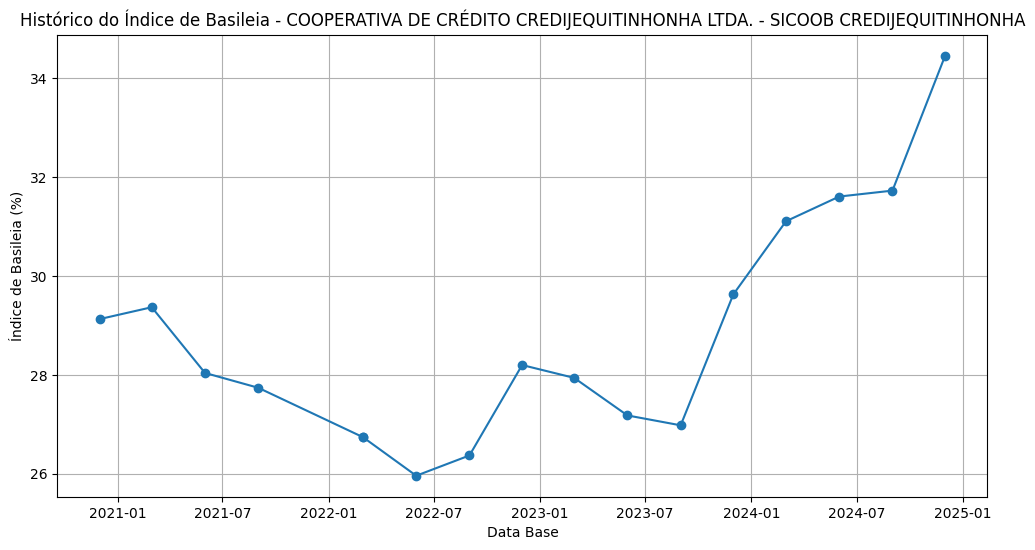

In [16]:
# Bloco de Visualização com Tratamento de Erros
# Garante que o notebook não falhe caso a tabela ainda não exista ou a query retorne vazio.
try:
    df_historico_basileia = duckdb_connection.execute(query_historico_basileia).df()

    plt.figure(figsize=(12, 6))
    plt.plot(df_historico_basileia['data_base'], df_historico_basileia['indice_de_basileia'], marker='o')
    plt.title(f'Histórico do Índice de Basileia - {CONFIG["TARGET_INSTITUTION"]}')
    plt.ylabel('Índice de Basileia (%)')
    plt.xlabel('Data Base')
    plt.grid(True)
    plt.show()
except duckdb.CatalogException as error:
    print(f"Erro: Tabela não encontrada ou erro na query. Detalhes: {error}")
except duckdb.Error as error:
    print(f"Ocorreu um erro: {error}")

In [17]:
# Encerra a conexão com o Data Warehouse para liberar recursos
duckdb_connection.close()